# **COMPONENTES DO GRUPO**

**Nome**                                     **RM**

Beatriz Falasca                           570086

Felipe Lessa                                570626

Gabriel Rodrigues                      568762

Gabrielle Trindade                     569092

Maria Eduarda Rodrigues         572951

# EC Sprint 3 — DATCROSS — Análise Exploratória de Dados (AED)

COMPONENTES DO GRUPO:   

Nome                                   RM  

Beatriz Falasca                       570086  
Felipe Lessa                          570626  
Gabriel Rodrigues                     568762
Gabrielle Trindade                    569092
Maria Eduarda Rodrigues               572951



**Projeto:** DATCROSS  
**Objetivo:** realizar uma AED robusta das internações por **Pneumonia, Infecção Urinária (ITU) e AVC**, avaliar qualidade e viabilidade dos dados para etapas posteriores de Machine Learning e identificar variáveis potencialmente úteis para um sistema que lê prontuários por linguagem natural e organiza pacientes com **perfil de menor complexidade para avaliação de alta/transferência**.

> **Nota metodológica importante:** esta análise é observacional e parte das variáveis clínicas da base é sintética. Associação estatística não será interpretada como causalidade nem como autorização de alta/transferência. A decisão clínica depende de protocolo e validação profissional.

## 1. Importação das bibliotecas e configuração

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu, chi2_contingency, kruskal
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['axes.grid']=True

## 2. Carregamento dos dados

As abas clínicas possuem três linhas de título/metadados antes do cabeçalho real. O carregamento usa `header=3` no Excel. Para acelerar a execução deste notebook já analisado, se existir um cache CSV local ele será utilizado; caso contrário, o Excel original será lido diretamente.

In [ ]:
ARQUIVO_XLSX = 'SIH_SP_Pneumonia_ITU_AVC_corrigido_com_ID_tecnico(2).xlsx'
if not os.path.exists(ARQUIVO_XLSX):
    candidatos=[f for f in os.listdir('.') if f.lower().endswith('.xlsx') and 'SIH_SP_Pneumonia_ITU_AVC' in f]
    if candidatos: ARQUIVO_XLSX=candidatos[0]

cache='/mnt/data/datcross_csv3'
if os.path.exists(cache):
    pneumonia=pd.read_csv(os.path.join(cache,'Pneumonia.csv'),low_memory=False)
    itu=pd.read_csv(os.path.join(cache,'ITU.csv'),low_memory=False)
    avc=pd.read_csv(os.path.join(cache,'AVC.csv'),low_memory=False)
else:
    pneumonia=pd.read_excel(ARQUIVO_XLSX,sheet_name='Pneumonia',header=3)
    itu=pd.read_excel(ARQUIVO_XLSX,sheet_name='Infecção Urinária',header=3)
    avc=pd.read_excel(ARQUIVO_XLSX,sheet_name='AVC',header=3)

bases={'Pneumonia':pneumonia,'Infecção Urinária':itu,'AVC':avc}
pd.DataFrame({k:{'linhas':len(v),'colunas':v.shape[1]} for k,v in bases.items()}).T

,linhas,colunas
Pneumonia,23506,75
Infecção Urinária,9807,76
AVC,19565,76


## 3. Validação inicial e estrutura das bases

In [ ]:
validacao=[]
for nome,df in bases.items():
    validacao.append({
        'Doença':nome,'Registros':len(df),'Colunas':df.shape[1],
        'IDs únicos':df['ID Técnico da Internação'].nunique(),
        'IDs duplicados':df['ID Técnico da Internação'].duplicated().sum(),
        'IDs ausentes':df['ID Técnico da Internação'].isna().sum(),
        'Duplicatas completas':df.duplicated().sum()
    })
validacao=pd.DataFrame(validacao)
display(validacao)
print('Total de internações:',sum(len(x) for x in bases.values()))
print('Diferença de esquema: Pneumonia possui 75 colunas; ITU e AVC possuem 76. A variável adicional é "Natureza do Hospital".')

,Doença,Registros,Colunas,IDs únicos,IDs duplicados,IDs ausentes,Duplicatas completas
0,Pneumonia,23506,75,23506,0,0,0
1,Infecção Urinária,9807,76,9807,0,0,0
2,AVC,19565,76,19565,0,0,0


Total de internações: 52878
Diferença de esquema: Pneumonia possui 75 colunas; ITU e AVC possuem 76. A variável adicional é "Natureza do Hospital".


### Interpretação

- A base contém **52.878 internações**: 23.506 Pneumonia, 9.807 ITU e 19.565 AVC.
- O **ID Técnico da Internação é único e completo** nas três abas, sendo adequado como chave primária técnica para a unificação.
- Há uma diferença estrutural pequena: Pneumonia possui uma coluna a menos que ITU/AVC. A concatenação deve preservar a união das colunas e registrar `NaN` onde a variável não existir.

## 4. Construção do dataset unificado

In [ ]:
# Padroniza o grupo e concatena pela união das colunas
for nome,df in bases.items():
    df['Grupo de Doença']=nome.upper().replace('INFECÇÃO URINÁRIA','ITU')
dataset_unificado=pd.concat([pneumonia,itu,avc],ignore_index=True,sort=False)
print('Dimensão unificada:',dataset_unificado.shape)
print('IDs únicos:',dataset_unificado['ID Técnico da Internação'].nunique())
display(dataset_unificado['Grupo de Doença'].value_counts().rename('n').to_frame())

Dimensão unificada: (52878, 76)
IDs únicos: 52878


,n
Grupo de Doença,
PNEUMONIA,23506
AVC,19565
ITU,9807


## 5. Dicionário de dados

O arquivo original já contém a aba **Dicionário de Dados**. No notebook, as variáveis utilizadas serão agrupadas por função analítica para facilitar a leitura por um novo colaborador.

In [ ]:
grupos_variaveis={
'Identificação':['ID Técnico da Internação','Grupo de Doença'],
'Demográficas':['Idade','Sexo','Raça/Cor','Região do Paciente','Município de Residência'],
'Administrativas':['Nome do Hospital','Especialidade do Leito','Complexidade','Caráter da Internação','Dias de Permanência','Gasto Total (R$)','Total Dias UTI (mês)'],
'Sinais vitais':['Frequência Cardíaca (bpm)','Frequência Respiratória (irpm)','Pressão Arterial Sistólica (mmHg)','Temperatura Axilar (°C)','Saturação de Oxigênio - SpO2 (%)','Nível de Consciência (Escala de Glasgow)','Diurese (mL/kg/h)','Glicemia Capilar (mg/dL)'],
'Desfechos':['Óbito','Status Vital'],
'Dispositivos':['Sonda Vesical de Demora','Sonda Nasogástrica','Sonda Nasoenteral','Cateter de Oxigênio','Intubação Orotraqueal','Ventilação Mecânica','Cateter Venoso Central','Cateter Central de Inserção Periférica (PICC)','Cateter Venoso Periférico']
}
dic=[]
for grupo,vars_ in grupos_variaveis.items():
    for v in vars_:
        dic.append({'Grupo':grupo,'Variável':v,'Presente na base':v in dataset_unificado.columns})
display(pd.DataFrame(dic))

,Grupo,Variável,Presente na base
0,Identificação,ID Técnico da Internação,True
1,Identificação,Grupo de Doença,True
2,Demográficas,Idade,True
3,Demográficas,Sexo,True
4,Demográficas,Raça/Cor,True
5,Demográficas,Região do Paciente,True
6,Demográficas,Município de Residência,True
7,Administrativas,Nome do Hospital,True
8,Administrativas,Especialidade do Leito,True
9,Administrativas,Complexidade,True


## 6. Qualidade dos dados e valores ausentes

In [ ]:
def resumo_missing(df):
    miss=pd.DataFrame({'Missing_real_n':df.isna().sum(),'Missing_real_%':df.isna().mean()*100})
    esp=[]
    for c in df.columns:
        s=df[c].astype(str)
        esp.append(((s.str.contains('Não Aplicável',na=False)).sum(),(s.eq('Não Informado')).sum()))
    miss['Não_Aplicável_n']=[x[0] for x in esp]
    miss['Não_Informado_n']=[x[1] for x in esp]
    return miss.sort_values('Missing_real_%',ascending=False)

for nome,df in bases.items():
    print(); print('---',nome,'---')
    display(resumo_missing(df).head(12))


--- Pneumonia ---


,Missing_real_n,Missing_real_%,Não_Aplicável_n,Não_Informado_n
Bairro do Hospital,1022,4.35,0,0
Logradouro do Hospital,1022,4.35,0,0
UF de Vinculação,0,0.00,0,0
Especialidade do Leito,0,0.00,0,0
Município de Residência,0,0.00,0,0
Data de Nascimento,0,0.00,0,0
Sexo,0,0.00,0,0
Total Dias UTI (mês),0,0.00,0,0
Tipo de UTI,0,0.00,0,0
Ano de Competência,0,0.00,0,0



--- Infecção Urinária ---


,Missing_real_n,Missing_real_%,Não_Aplicável_n,Não_Informado_n
Logradouro do Hospital,563,5.74,0,0
Bairro do Hospital,563,5.74,0,0
UF de Vinculação,0,0.00,0,0
Ano de Competência,0,0.00,0,0
Município de Residência,0,0.00,0,0
Data de Nascimento,0,0.00,0,0
Sexo,0,0.00,0,0
Total Dias UTI (mês),0,0.00,0,0
Tipo de UTI,0,0.00,0,0
Gasto Total (R$),0,0.00,0,0



--- AVC ---


,Missing_real_n,Missing_real_%,Não_Aplicável_n,Não_Informado_n
Logradouro do Hospital,967,4.94,0,0
Bairro do Hospital,967,4.94,0,0
UF de Vinculação,0,0.00,0,0
Ano de Competência,0,0.00,0,0
Município de Residência,0,0.00,0,0
Data de Nascimento,0,0.00,0,0
Sexo,0,0.00,0,0
Total Dias UTI (mês),0,0.00,0,0
Tipo de UTI,0,0.00,0,0
Gasto Total (R$),0,0.00,0,0


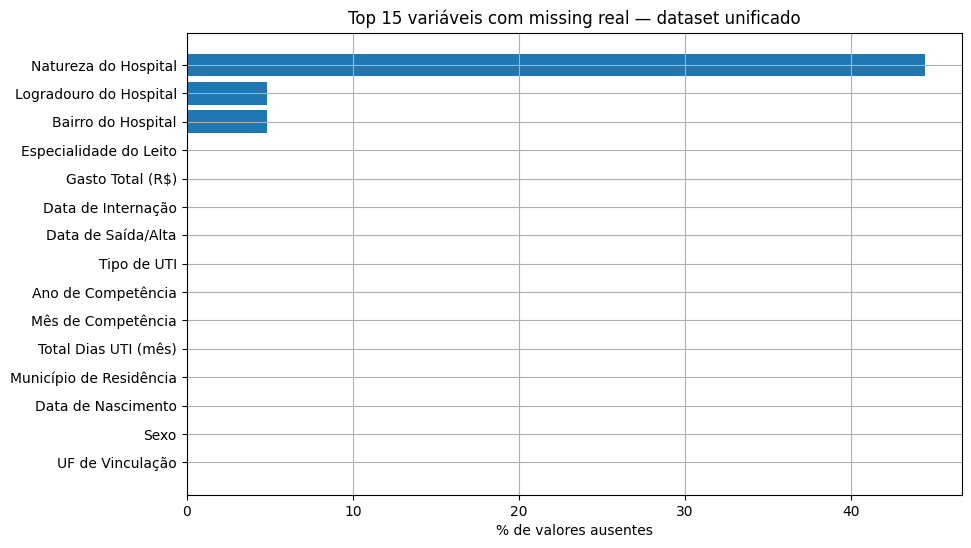

In [ ]:
# Gráfico: missing real por variável (top 15) no dataset unificado
m=(dataset_unificado.isna().mean()*100).sort_values(ascending=False).head(15).sort_values()
plt.figure(figsize=(10,6)); plt.barh(m.index,m.values); plt.xlabel('% de valores ausentes'); plt.title('Top 15 variáveis com missing real — dataset unificado'); plt.show()

### Insight de qualidade

Os `NaN` reais concentram-se principalmente em **Bairro do Hospital** e **Logradouro do Hospital** (aprox. 4–6% por doença) e na diferença estrutural da coluna `Natureza do Hospital`. Já variáveis específicas de outras doenças aparecem corretamente como **“Não Aplicável (NA)”** e não devem ser confundidas com ausência de informação. Vacinação contém uma fração relevante de **“Não Informado”**, devendo ser analisada separadamente da categoria “Não”.

## 7. Estatística descritiva e distribuição das variáveis

In [ ]:
num=['Idade','Dias de Permanência','Gasto Total (R$)','Total Dias UTI (mês)','Frequência Cardíaca (bpm)','Frequência Respiratória (irpm)','Pressão Arterial Sistólica (mmHg)','Temperatura Axilar (°C)','Saturação de Oxigênio - SpO2 (%)','Nível de Consciência (Escala de Glasgow)','Diurese (mL/kg/h)','Glicemia Capilar (mg/dL)']
res=[]
for nome,df in bases.items():
    for c in num:
        x=pd.to_numeric(df[c],errors='coerce').dropna()
        res.append({'Doença':nome,'Variável':c,'n':len(x),'Média':x.mean(),'Mediana':x.median(),'DP':x.std(),'Q1':x.quantile(.25),'Q3':x.quantile(.75),'Mín':x.min(),'Máx':x.max(),'Assimetria':x.skew()})
resumo_num=pd.DataFrame(res)
display(resumo_num[resumo_num['Variável'].isin(['Idade','Dias de Permanência','Gasto Total (R$)','Total Dias UTI (mês)'])].round(2))

,Doença,Variável,n,Média,Mediana,DP,Q1,Q3,Mín,Máx,Assimetria
0,Pneumonia,Idade,23506,65.70,69.00,18.76,54.00,80.00,18.00,99.00,-0.56
1,Pneumonia,Dias de Permanência,23506,9.32,7.00,9.77,4.00,11.00,0.00,235.00,4.05
2,Pneumonia,Gasto Total (R$),23506,"1,720.11",816.78,"3,249.45",679.86,"1,196.90",21.98,"71,771.39",6.01
3,Pneumonia,Total Dias UTI (mês),23506,1.03,0.00,3.96,0.00,0.00,0.00,75.00,5.78
12,Infecção Urinária,Idade,9807,67.08,71.00,19.33,56.00,81.00,18.00,99.00,-0.79
13,Infecção Urinária,Dias de Permanência,9807,7.53,6.00,8.39,3.00,9.00,0.00,112.00,4.51
14,Infecção Urinária,Gasto Total (R$),9807,739.55,398.66,"1,484.42",253.06,655.53,21.98,"28,678.02",8.46
15,Infecção Urinária,Total Dias UTI (mês),9807,0.24,0.00,1.63,0.00,0.00,0.00,30.00,9.78
24,AVC,Idade,19565,64.35,66.00,14.75,55.00,75.00,18.00,99.00,-0.41
25,AVC,Dias de Permanência,19565,8.54,5.00,10.40,3.00,10.00,0.00,136.00,3.24


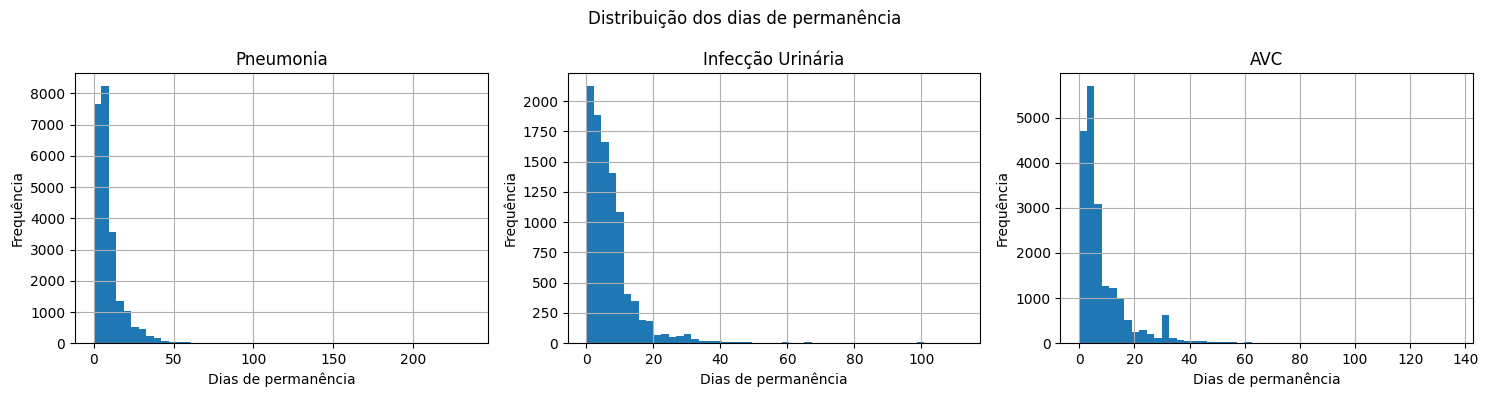

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(nome,df) in zip(axes,bases.items()):
    x=df['Dias de Permanência']
    ax.hist(x,bins=50); ax.set_title(nome); ax.set_xlabel('Dias de permanência'); ax.set_ylabel('Frequência')
plt.suptitle('Distribuição dos dias de permanência'); plt.tight_layout(); plt.show()

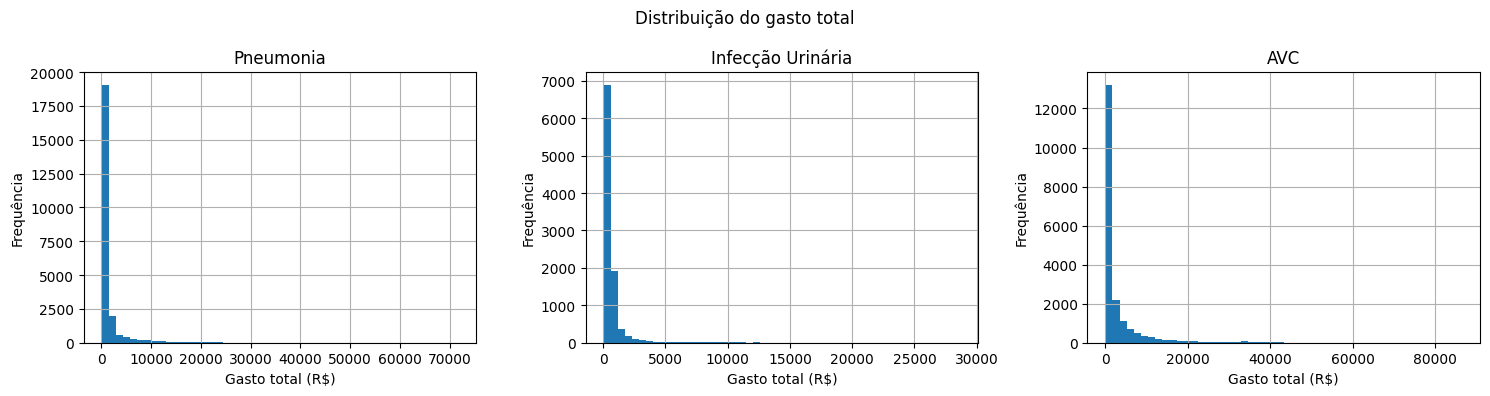

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(nome,df) in zip(axes,bases.items()):
    x=df['Gasto Total (R$)']
    ax.hist(x,bins=50); ax.set_title(nome); ax.set_xlabel('Gasto total (R$)'); ax.set_ylabel('Frequência')
plt.suptitle('Distribuição do gasto total'); plt.tight_layout(); plt.show()

### Interpretação das distribuições

- **Pneumonia:** permanência mediana 7 dias (média 9,32) e gasto mediano R$ 816,78 (média R$ 1.720,11).
- **ITU:** permanência mediana 6 dias (média 7,53) e gasto mediano R$ 398,66 (média R$ 739,55).
- **AVC:** permanência mediana 5 dias (média 8,54) e gasto mediano R$ 970,97 (média R$ 3.217,06).
- Permanência, gasto e dias de UTI apresentam **assimetria à direita**, portanto mediana/IQR e correlação de Spearman são mais adequados como medidas principais.

## 8. Outliers

In [ ]:
out=[]
for nome,df in bases.items():
    for c in ['Idade','Dias de Permanência','Gasto Total (R$)','Total Dias UTI (mês)']:
        x=pd.to_numeric(df[c],errors='coerce').dropna(); q1=x.quantile(.25); q3=x.quantile(.75); iqr=q3-q1; lo=q1-1.5*iqr; hi=q3+1.5*iqr
        mask=(x<lo)|(x>hi)
        out.append({'Doença':nome,'Variável':c,'Limite inferior':lo,'Limite superior':hi,'Outliers n':mask.sum(),'Outliers %':100*mask.mean()})
outliers=pd.DataFrame(out)
display(outliers.round(2))

,Doença,Variável,Limite inferior,Limite superior,Outliers n,Outliers %
0,Pneumonia,Idade,15.00,119.00,0,0.00
1,Pneumonia,Dias de Permanência,-6.50,21.50,1970,8.38
2,Pneumonia,Gasto Total (R$),-95.70,"1,972.45",3205,13.63
3,Pneumonia,Total Dias UTI (mês),0.00,0.00,2683,11.41
4,Infecção Urinária,Idade,18.50,118.50,44,0.45
5,Infecção Urinária,Dias de Permanência,-6.00,18.00,611,6.23
6,Infecção Urinária,Gasto Total (R$),-350.64,"1,259.23",899,9.17
7,Infecção Urinária,Total Dias UTI (mês),0.00,0.00,385,3.93
8,AVC,Idade,25.00,105.00,153,0.78
9,AVC,Dias de Permanência,-7.50,20.50,1963,10.03


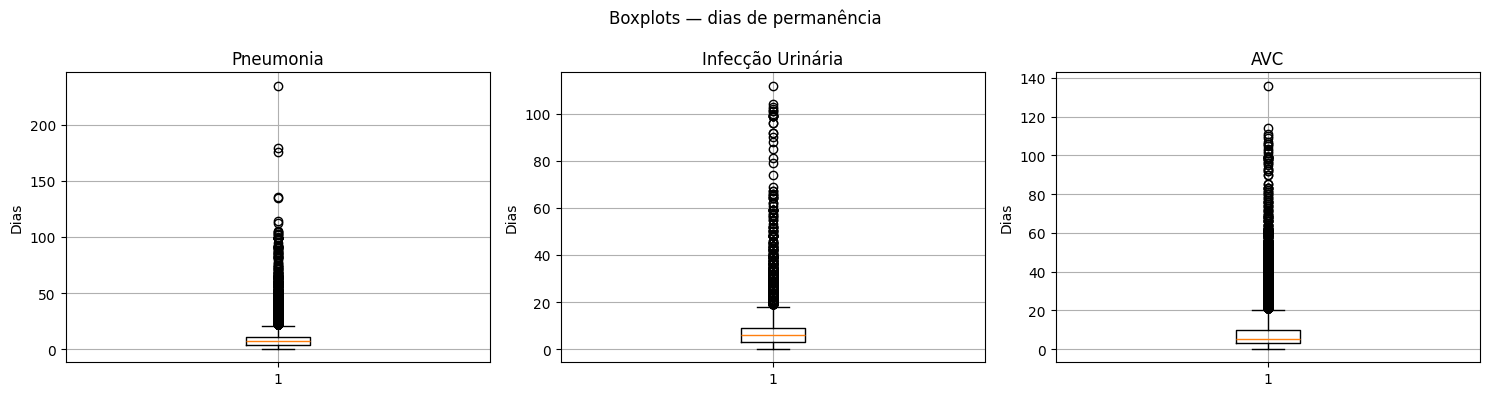

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(nome,df) in zip(axes,bases.items()):
    ax.boxplot(df['Dias de Permanência'],vert=True); ax.set_title(nome); ax.set_ylabel('Dias')
plt.suptitle('Boxplots — dias de permanência'); plt.tight_layout(); plt.show()

### Decisão sobre outliers

Os valores extremos de permanência e gasto **não devem ser excluídos automaticamente**: longas internações e gastos elevados são clinicamente/administrativamente plausíveis e justamente relevantes para o projeto. O critério IQR identifica casos extremos estatísticos, não erros. Valores impossíveis devem ser tratados separadamente após validação de domínio.

## 9. Perfil demográfico

In [ ]:
for nome,df in bases.items():
    print(); print(nome)
    display(pd.DataFrame({'n':df['Sexo'].value_counts(),'percentual':df['Sexo'].value_counts(normalize=True)*100}).round(2))
    print('Idade mediana:',df['Idade'].median(),'anos')


Pneumonia


,n,percentual
Sexo,,
Masculino,12207,51.93
Feminino,11299,48.07


Idade mediana: 69.0 anos

Infecção Urinária


,n,percentual
Sexo,,
Feminino,5831,59.46
Masculino,3976,40.54


Idade mediana: 71.0 anos

AVC


,n,percentual
Sexo,,
Masculino,9912,50.66
Feminino,9653,49.34


Idade mediana: 66.0 anos


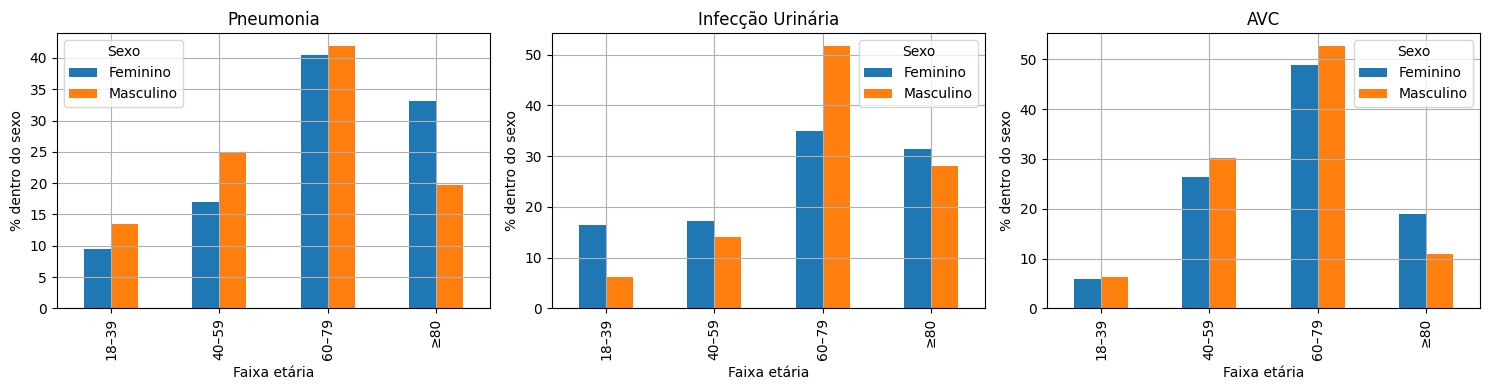

In [ ]:
# Faixas etárias
for df in bases.values():
    df['Faixa Etária']=pd.cut(df['Idade'],bins=[17,39,59,79,200],labels=['18–39','40–59','60–79','≥80'])
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(nome,df) in zip(axes,bases.items()):
    tab=pd.crosstab(df['Faixa Etária'],df['Sexo'],normalize='columns')*100
    tab.plot(kind='bar',ax=ax); ax.set_title(nome); ax.set_ylabel('% dentro do sexo'); ax.set_xlabel('Faixa etária')
plt.tight_layout(); plt.show()

## 10. Perfil hospitalar e regional

In [ ]:
for nome,df in bases.items():
    print(); print('###',nome)
    print('Top regiões:'); display(df['Região do Paciente'].value_counts().head(6).to_frame('Internações'))
    print('Especialidade de leito:'); display(df['Especialidade do Leito'].value_counts().head(8).to_frame('Internações'))
    print('Top hospitais por gasto total:'); display(df.groupby('Nome do Hospital')['Gasto Total (R$)'].sum().sort_values(ascending=False).head(10).to_frame('Gasto total').round(2))


### Pneumonia
Top regiões:


,Internações
Região do Paciente,
Leste,9194
Sul,6398
Norte,4404
Fora do Município de SP,1626
Oeste,1253
Centro,631


Especialidade de leito:


,Internações
Especialidade do Leito,
Clínica Médica,23212
Cirurgia,265
Pediatria,27
Hospital Dia - Cirúrgicos,1
Hospital Dia - Geriatria,1


Top hospitais por gasto total:


...

,Internações
Região do Paciente,
Leste,7996
Sul,5322
Norte,2746
Fora do Município de SP,1900
Oeste,1038
Centro,563


Especialidade de leito:


,Internações
Especialidade do Leito,
Clínica Médica,16573
Cirurgia,2982
Pediatria,4
Hospital Dia - Geriatria,4
Crônicos,2


Top hospitais por gasto total:


,Gasto total
Nome do Hospital,
Hospital das Clínicas da FMUSP,"20,404,791.39"
Hospital Santa Marcelina (São Paulo),"9,747,950.73"
Hospital São Paulo (UNIFESP),"2,897,720.27"
Conjunto Hospitalar do Mandaqui,"2,722,683.66"
Hospital Municipal Prof. Alípio Corrêa Netto - Ermelino Matarazzo,"2,447,162.13"
Santa Casa de São Paulo (Hospital Central),"2,332,089.71"
Hospital Municipal Dr. Fernando Mauro Pires da Rocha - Campo Limpo,"2,309,451.50"
Hospital Municipal Dr. Cármino Caricchio - Tatuapé,"2,038,942.20"
Não identificado,"1,761,155.56"


### Observação de consistência

Embora o recorte seja de **pacientes adultos**, aparecem alguns registros com especialidade de leito **Pediatria** (27 em Pneumonia, 16 em ITU e 4 em AVC). Isso merece checagem de codificação/uso do leito, mas não deve ser removido automaticamente. A base também não contém capacidade instalada de leitos; portanto é possível analisar **internações por especialidade**, mas não concluir qual região possui mais leitos disponíveis sem integração com CNES.

## 11. Comorbidades por doença, sexo e idade

In [ ]:
comorb=[c for c in dataset_unificado.columns if '(comorbidade)' in c]
prev=[]
for nome,df in bases.items():
    for c in comorb:
        if c in df:
            valid=df[c].isin(['Sim','Não']); pct=100*(df.loc[valid,c]=='Sim').mean() if valid.any() else np.nan
            prev.append({'Doença':nome,'Comorbidade':c.replace(' (comorbidade)',''),'Prevalência %':pct})
prev=pd.DataFrame(prev)
for nome in bases:
    display(prev[prev['Doença']==nome].sort_values('Prevalência %',ascending=False).head(10).round(2))

,Doença,Comorbidade,Prevalência %
0,Pneumonia,Hipertensão Arterial,59.72
1,Pneumonia,Diabetes Mellitus,40.18
8,Pneumonia,DPOC - Doença Pulmonar Obstrutiva Crônica,37.46
4,Pneumonia,Insuficiência Cardíaca,22.66
6,Pneumonia,Obesidade,22.32
9,Pneumonia,Demência / Doença de Alzheimer,14.31
5,Pneumonia,Doença Renal Crônica,11.24
10,Pneumonia,Hiperplasia Prostática Benigna,10.64
3,Pneumonia,Fibrilação Atrial,10.10
2,Pneumonia,Sequela de AVC Prévio,7.91


,Doença,Comorbidade,Prevalência %
12,Infecção Urinária,Hipertensão Arterial,60.54
13,Infecção Urinária,Diabetes Mellitus,40.87
23,Infecção Urinária,Litíase Urinária / Cálculo Renal,35.19
18,Infecção Urinária,Obesidade,21.87
21,Infecção Urinária,Demência / Doença de Alzheimer,15.95
16,Infecção Urinária,Insuficiência Cardíaca,13.46
22,Infecção Urinária,Hiperplasia Prostática Benigna,9.83
15,Infecção Urinária,Fibrilação Atrial,8.22
20,Infecção Urinária,DPOC - Doença Pulmonar Obstrutiva Crônica,8.11
19,Infecção Urinária,Neoplasia / Câncer,7.82


,Doença,Comorbidade,Prevalência %
24,AVC,Hipertensão Arterial,58.05
25,AVC,Diabetes Mellitus,40.95
27,AVC,Fibrilação Atrial,34.32
26,AVC,Sequela de AVC Prévio,30.37
28,AVC,Insuficiência Cardíaca,27.54
30,AVC,Obesidade,22.18
33,AVC,Demência / Doença de Alzheimer,13.07
34,AVC,Hiperplasia Prostática Benigna,11.15
32,AVC,DPOC - Doença Pulmonar Obstrutiva Crônica,10.33
29,AVC,Doença Renal Crônica,10.01


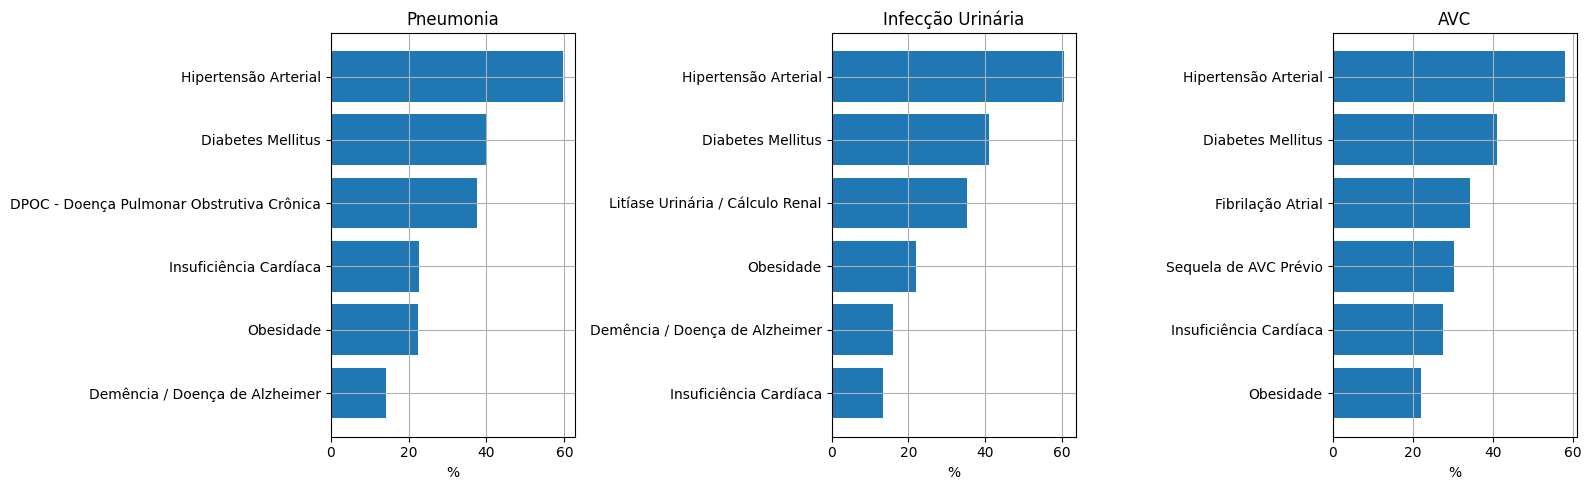

In [ ]:
# Gráfico das cinco comorbidades mais prevalentes por doença
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,nome in zip(axes,bases):
    t=prev[prev['Doença']==nome].nlargest(6,'Prevalência %').sort_values('Prevalência %')
    ax.barh(t['Comorbidade'],t['Prevalência %']); ax.set_title(nome); ax.set_xlabel('%')
plt.tight_layout(); plt.show()

In [ ]:
# Sexo x comorbidade — diferenças proporcionais
sex_rows=[]
for nome,df in bases.items():
    for c in comorb:
        if c not in df: continue
        vals={}
        for sex in ['Feminino','Masculino']:
            sub=df[df['Sexo']==sex]; valid=sub[c].isin(['Sim','Não']); vals[sex]=100*(sub.loc[valid,c]=='Sim').mean() if valid.any() else np.nan
        sex_rows.append({'Doença':nome,'Comorbidade':c.replace(' (comorbidade)',''),'Feminino %':vals['Feminino'],'Masculino %':vals['Masculino'],'Diferença pp (M-F)':vals['Masculino']-vals['Feminino']})
sex_comorb=pd.DataFrame(sex_rows)
for nome in bases:
    display(sex_comorb[sex_comorb['Doença']==nome].assign(absdiff=lambda x:x['Diferença pp (M-F)'].abs()).nlargest(6,'absdiff').drop(columns='absdiff').round(2))

,Doença,Comorbidade,Feminino %,Masculino %,Diferença pp (M-F)
10,Pneumonia,Hiperplasia Prostática Benigna,0.00,20.49,20.49
0,Pneumonia,Hipertensão Arterial,63.09,56.59,-6.50
9,Pneumonia,Demência / Doença de Alzheimer,16.05,12.69,-3.37
1,Pneumonia,Diabetes Mellitus,41.38,39.06,-2.32
3,Pneumonia,Fibrilação Atrial,9.77,10.40,0.63
5,Pneumonia,Doença Renal Crônica,11.50,11.00,-0.49


,Doença,Comorbidade,Feminino %,Masculino %,Diferença pp (M-F)
22,Infecção Urinária,Hiperplasia Prostática Benigna,0.00,24.25,24.25
13,Infecção Urinária,Diabetes Mellitus,39.15,43.39,4.23
12,Infecção Urinária,Hipertensão Arterial,59.18,62.53,3.34
21,Infecção Urinária,Demência / Doença de Alzheimer,14.97,17.38,2.41
23,Infecção Urinária,Litíase Urinária / Cálculo Renal,36.07,33.90,-2.16
16,Infecção Urinária,Insuficiência Cardíaca,14.11,12.50,-1.61


,Doença,Comorbidade,Feminino %,Masculino %,Diferença pp (M-F)
34,AVC,Hiperplasia Prostática Benigna,0.00,22.00,22.00
24,AVC,Hipertensão Arterial,59.40,56.73,-2.67
33,AVC,Demência / Doença de Alzheimer,13.99,12.19,-1.80
27,AVC,Fibrilação Atrial,33.71,34.91,1.20
30,AVC,Obesidade,22.59,21.77,-0.82
28,AVC,Insuficiência Cardíaca,27.84,27.25,-0.59


### Principais comorbidades

- **Pneumonia:** HAS 59,7%, DM 40,2%, DPOC 37,5%.
- **ITU:** HAS 60,5%, DM 40,9%, litíase urinária 35,2%.
- **AVC:** HAS 58,0%, DM 41,0%, fibrilação atrial 34,3%, sequela de AVC prévio 30,4%.
- A HPB aparece apenas em homens, como esperado pela natureza da condição; outras diferenças por sexo são menores e devem ser interpretadas em percentuais, não contagens absolutas.

## 12. Número de comorbidades × permanência

In [ ]:
for nome,df in bases.items():
    df['Número de Comorbidades']=sum((df[c]=='Sim').astype(int) for c in comorb if c in df)
    rho,p=spearmanr(df['Número de Comorbidades'],df['Dias de Permanência'])
    print(f'{nome}: Spearman rho={rho:.3f}; p={p:.3g}')
    display(df.groupby('Número de Comorbidades')['Dias de Permanência'].agg(['count','median','mean']).head(9).round(2))

Pneumonia: Spearman rho=0.007; p=0.265


,count,median,mean
Número de Comorbidades,,,
0,1312,7.00,9.01
1,4338,7.00,9.26
2,6631,7.00,9.36
3,6072,7.00,9.32
4,3472,7.00,9.61
5,1315,7.00,9.23
6,301,6.00,8.12
7,59,7.00,8.14
8,6,4.00,4.50


Infecção Urinária: Spearman rho=0.047; p=3.71e-06


,count,median,mean
Número de Comorbidades,,,
0,659,5.00,6.84
1,1973,5.00,7.17
2,2979,6.00,7.71
3,2347,6.00,7.67
4,1317,6.00,7.68
5,400,6.00,7.78
6,116,6.00,7.43
7,14,8.50,11.86
8,2,6.00,6.00


AVC: Spearman rho=0.035; p=9.56e-07


,count,median,mean
Número de Comorbidades,,,
0,726,5.00,8.21
1,3057,5.00,8.24
2,5260,5.00,8.55
3,5185,5.00,8.64
4,3382,5.00,8.54
5,1431,6.00,8.83
6,437,6.00,9.10
7,75,5.00,8.64
8,11,7.00,7.73


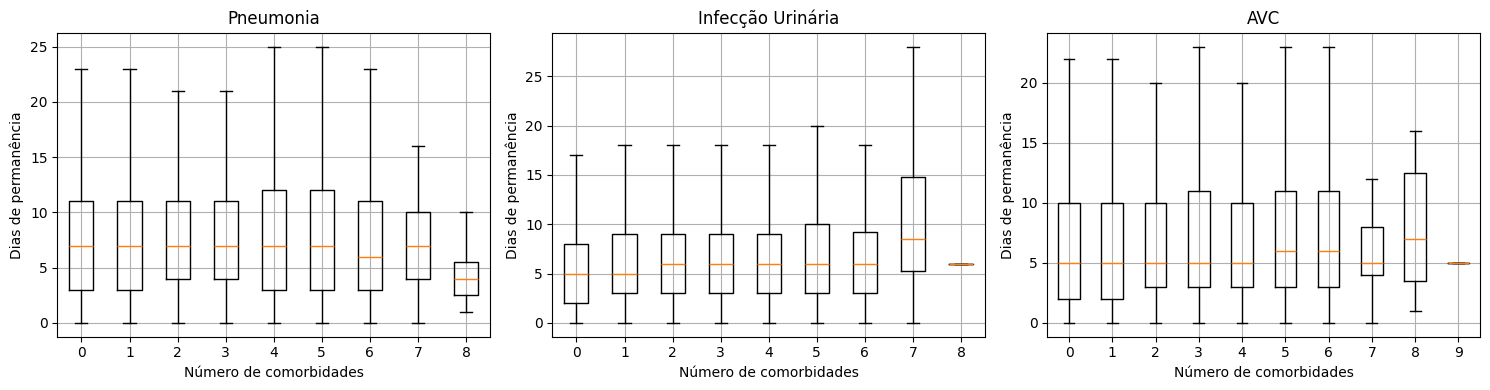

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(nome,df) in zip(axes,bases.items()):
    cats=sorted(df['Número de Comorbidades'].unique())
    ax.boxplot([df.loc[df['Número de Comorbidades']==c,'Dias de Permanência'] for c in cats],labels=cats,showfliers=False)
    ax.set_title(nome); ax.set_xlabel('Número de comorbidades'); ax.set_ylabel('Dias de permanência')
plt.tight_layout(); plt.show()

### Insight

A carga de comorbidades teve relação **muito fraca** com permanência: rho≈0,007 em Pneumonia, 0,047 em ITU e 0,035 em AVC. Em uma amostra grande, p-valores podem ser pequenos mesmo com efeito praticamente irrelevante. Portanto, **número de comorbidades isoladamente não parece suficiente para triagem de transferência** nesta base.

## 13. Permanência × custo e UTI

In [ ]:
rows=[]
for nome,df in bases.items():
    for a,b in [('Dias de Permanência','Gasto Total (R$)'),('Total Dias UTI (mês)','Dias de Permanência')]:
        r,p=spearmanr(df[a],df[b])
        rows.append({'Doença':nome,'Relação':f'{a} × {b}','Spearman rho':r,'p':p})
display(pd.DataFrame(rows).round(4))

,Doença,Relação,Spearman rho,p
0,Pneumonia,Dias de Permanência × Gasto Total (R$),0.61,0.00
1,Pneumonia,Total Dias UTI (mês) × Dias de Permanência,0.26,0.00
2,Infecção Urinária,Dias de Permanência × Gasto Total (R$),0.59,0.00
3,Infecção Urinária,Total Dias UTI (mês) × Dias de Permanência,0.17,0.00
4,AVC,Dias de Permanência × Gasto Total (R$),0.42,0.00
5,AVC,Total Dias UTI (mês) × Dias de Permanência,0.30,0.00


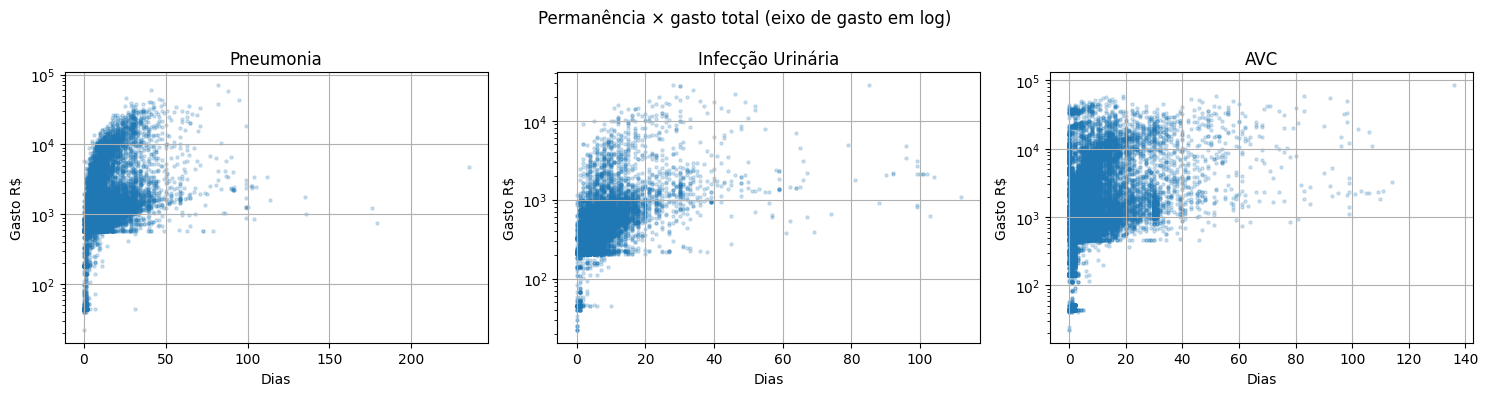

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(nome,df) in zip(axes,bases.items()):
    ax.scatter(df['Dias de Permanência'],df['Gasto Total (R$)'],s=5,alpha=.2); ax.set_title(nome); ax.set_xlabel('Dias'); ax.set_ylabel('Gasto R$'); ax.set_yscale('log')
plt.suptitle('Permanência × gasto total (eixo de gasto em log)'); plt.tight_layout(); plt.show()

### Insight

A relação mais consistente da AED é **permanência × gasto**, com Spearman rho≈0,608 em Pneumonia, 0,586 em ITU e 0,421 em AVC. Dias de UTI também se associam positivamente à permanência, especialmente em AVC (rho≈0,301). Isso confirma que tempo e uso de recursos são dimensões importantes de complexidade, mas gasto é parcialmente consequência direta da permanência e não deve ser usado como proxy clínico de estabilidade.

# 14. AED específica — Pneumonia

In [ ]:
p=pneumonia
pairs=[('Saturação de Oxigênio - SpO2 (%)','Dias de Permanência'),('Frequência Respiratória (irpm)','Dias de Permanência'),('Idade','Dias de Permanência')]
for a,b in pairs:
    r,pv=spearmanr(p[a],p[b]); print(f'{a} × {b}: rho={r:.3f}, p={pv:.3g}')
for c in ['Ventilação Mecânica','DPOC - Doença Pulmonar Obstrutiva Crônica (comorbidade)']:
    display(p.groupby(c)['Dias de Permanência'].agg(['count','median','mean']).round(2))

Saturação de Oxigênio - SpO2 (%) × Dias de Permanência: rho=0.009, p=0.188
Frequência Respiratória (irpm) × Dias de Permanência: rho=0.004, p=0.563
Idade × Dias de Permanência: rho=0.011, p=0.0833


,count,median,mean
Ventilação Mecânica,,,
Não,19963,7.00,9.19
Sim,3543,7.00,10.05


,count,median,mean
DPOC - Doença Pulmonar Obstrutiva Crônica (comorbidade),,,
Não,14700,7.00,9.32
Sim,8806,7.00,9.33


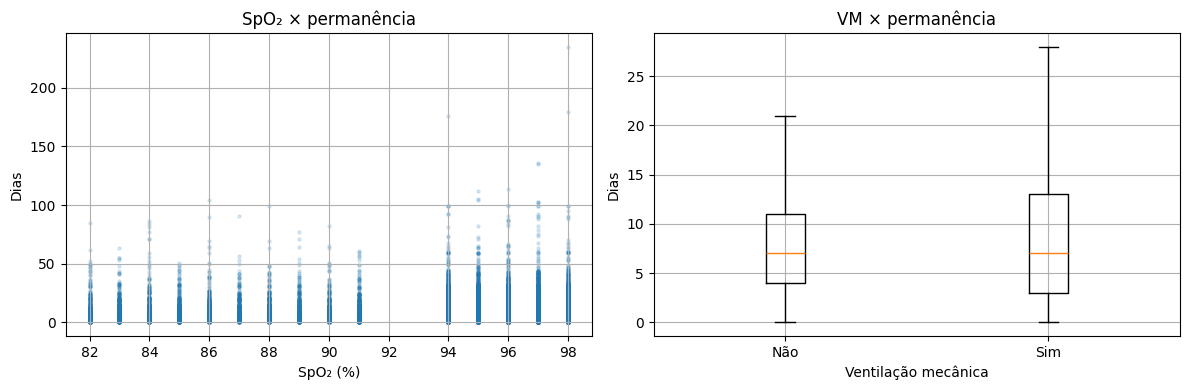

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(p['Saturação de Oxigênio - SpO2 (%)'],p['Dias de Permanência'],s=5,alpha=.15); axes[0].set_xlabel('SpO₂ (%)'); axes[0].set_ylabel('Dias'); axes[0].set_title('SpO₂ × permanência')
groups=[p.loc[p['Ventilação Mecânica']==x,'Dias de Permanência'] for x in ['Não','Sim']]
axes[1].boxplot(groups,labels=['Não','Sim'],showfliers=False); axes[1].set_xlabel('Ventilação mecânica'); axes[1].set_ylabel('Dias'); axes[1].set_title('VM × permanência')
plt.tight_layout(); plt.show()

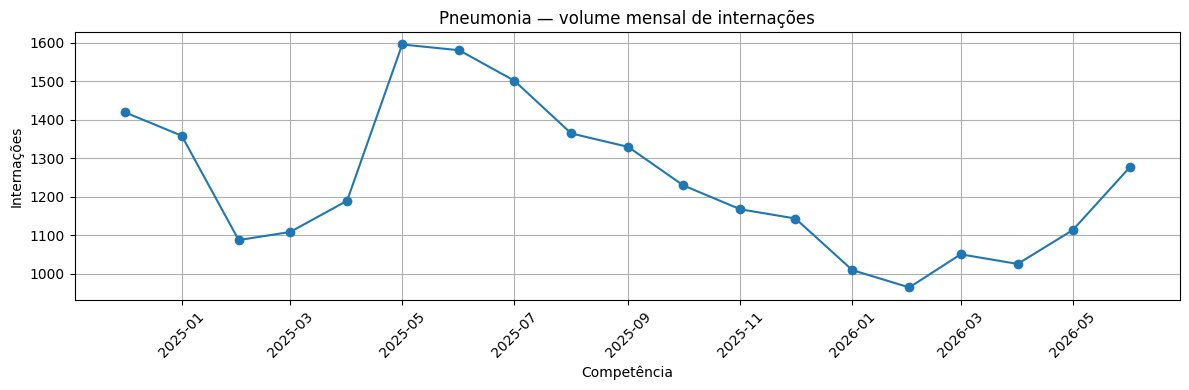

In [ ]:
# Sazonalidade
p['Ano-Mês']=pd.to_datetime(dict(year=p['Ano de Competência'],month=p['Mês de Competência'],day=1))
t=p.groupby('Ano-Mês').size()
plt.figure(figsize=(12,4)); plt.plot(t.index,t.values,marker='o'); plt.title('Pneumonia — volume mensal de internações'); plt.ylabel('Internações'); plt.xlabel('Competência'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [ ]:
# Etiologia x tratamento
ct=pd.crosstab(p['Etiologia da Pneumonia'],p['Tratamento Etiológico'],normalize='index')*100
display(ct.round(1))
# Vacinação x óbito (mantendo Não Informado separado)
display((pd.crosstab(p['Vacina contra Influenza'],p['Óbito'],normalize='index')*100).round(1))

Tratamento Etiológico,Amoxicilina + Clavulanato,Ceftriaxona + Azitromicina,Meropenem,Piperacilina + Tazobactam
Etiologia da Pneumonia,,,,
Bacteriana Atípica,23.80,26.10,25.10,25.10
Bacteriana Típica (S. pneumoniae),25.60,25.00,24.80,24.60
Não Identificada,24.50,25.40,24.70,25.40
Viral (Influenza/VSR/COVID),25.80,25.40,24.00,24.80


Óbito,0,1
Vacina contra Influenza,,
Não,81.90,18.10
Não Informado,82.20,17.80
Sim,82.30,17.70


### Pneumonia — interpretação

Contrariamente à hipótese clínica inicial, **SpO₂ e frequência respiratória praticamente não se correlacionaram com permanência** (rho≈0,009 e 0,004). VM e DPOC também apresentaram medianas de permanência muito semelhantes entre grupos. Vacinação contra influenza mostrou letalidade praticamente igual entre categorias nesta base. Esses resultados sugerem que as variáveis clínicas sintéticas **não foram geradas com dependência realista em relação à duração da internação**, portanto não devem ser usadas para inferir efeito causal ou construir regra de alta sem revisão da geração sintética.

# 15. AED específica — Infecção Urinária

In [ ]:
u=itu
for a in ['Diurese (mL/kg/h)','Temperatura Axilar (°C)','Idade']:
    r,pv=spearmanr(u[a],u['Dias de Permanência']); print(f'{a} × permanência: rho={r:.3f}, p={pv:.3g}')
for c in ['Sonda Vesical de Demora','Doença Renal Crônica (comorbidade)','Diabetes Mellitus (comorbidade)']:
    display(u.groupby(c)['Dias de Permanência'].agg(['count','median','mean']).round(2))

Diurese (mL/kg/h) × permanência: rho=-0.023, p=0.0233
Temperatura Axilar (°C) × permanência: rho=0.014, p=0.172
Idade × permanência: rho=0.106, p=6.32e-26


,count,median,mean
Sonda Vesical de Demora,,,
Não,2901,6.00,7.53
Sim,6906,6.00,7.53


,count,median,mean
Doença Renal Crônica (comorbidade),,,
Não,9081,6.00,7.53
Sim,726,6.00,7.53


,count,median,mean
Diabetes Mellitus (comorbidade),,,
Não,5799,5.00,7.46
Sim,4008,6.00,7.64


Resultado de Urocultura,Escherichia coli,Klebsiella pneumoniae,Negativa / Não Isolado,Proteus mirabilis,Pseudomonas aeruginosa
Sonda Vesical de Demora,,,,,
Não,53.90,18.30,11.50,8.50,7.70
Sim,54.30,19.10,11.40,8.10,7.20


Qui-quadrado p=0.7121; V de Cramér=0.015


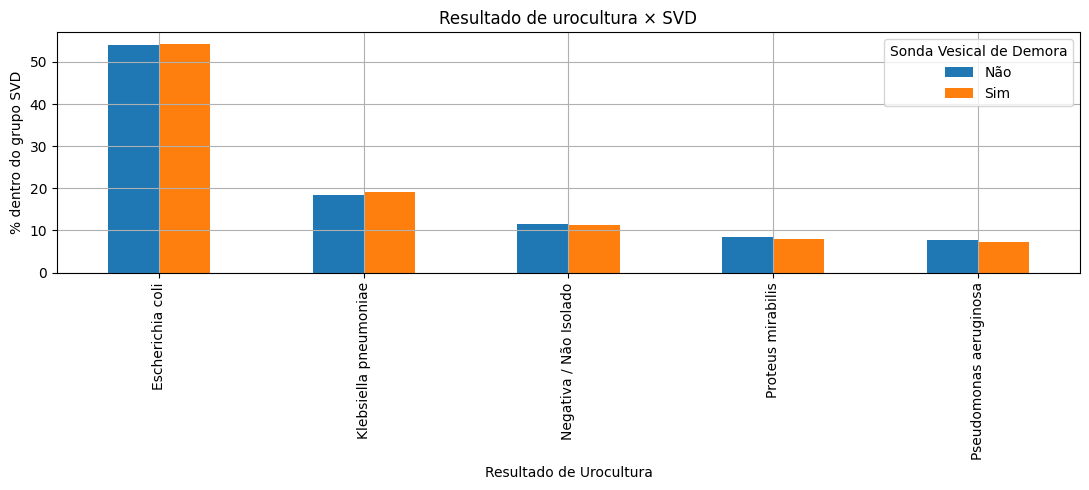

In [ ]:
# SVD x urocultura
ct=pd.crosstab(u['Sonda Vesical de Demora'],u['Resultado de Urocultura'])
prop=ct.div(ct.sum(axis=1),axis=0)*100
display(prop.round(1))
chi2,pv,dof,exp=chi2_contingency(ct)
n=ct.to_numpy().sum(); k=min(ct.shape)-1; v=(chi2/(n*k))**0.5
print(f'Qui-quadrado p={pv:.4g}; V de Cramér={v:.3f}')
prop.T.plot(kind='bar',figsize=(11,5)); plt.ylabel('% dentro do grupo SVD'); plt.title('Resultado de urocultura × SVD'); plt.tight_layout(); plt.show()

### ITU — interpretação

A relação **SVD × urocultura** é muito pequena nesta base: a distribuição dos agentes é quase idêntica entre pacientes com e sem SVD, e o V de Cramér deve ser interpretado pela magnitude, não apenas pelo p-valor. Diurese e temperatura têm correlação praticamente nula com permanência. Diabetes apresenta pequena diferença de mediana (6 vs. 5 dias), enquanto DRC mostra medianas semelhantes. Assim, novamente, a estrutura sintética parece limitar a capacidade de reproduzir dependências clínicas esperadas.

# 16. AED específica — AVC

In [ ]:
a=avc
r,pv=spearmanr(a['Nível de Consciência (Escala de Glasgow)'],a['Dias de Permanência'])
print(f'Glasgow × permanência: rho={r:.3f}, p={pv:.3g}')
display(a.groupby('Óbito')['Nível de Consciência (Escala de Glasgow)'].agg(['count','median','mean']).round(2))
display(a['Tomografia Positiva para AVC'].value_counts().to_frame('n'))
display(a['EEG Positivo para AVC'].value_counts().to_frame('n'))

Glasgow × permanência: rho=-0.056, p=7.64e-15


,count,median,mean
Óbito,,,
0,16795,15.00,14.85
1,2770,7.00,7.08


,n
Tomografia Positiva para AVC,
Isquemia Aguda,15275
Hemorragia Intraparenquimatosa,3544
Transformação Hemorrágica,746


,n
EEG Positivo para AVC,
Sem alterações agudas,6552
Atividade epileptiforme,6543
Lentificação focal,6470


,Letalidade %
Tomografia Positiva para AVC,
Isquemia Aguda,14.27
Hemorragia Intraparenquimatosa,13.94
Transformação Hemorrágica,12.87


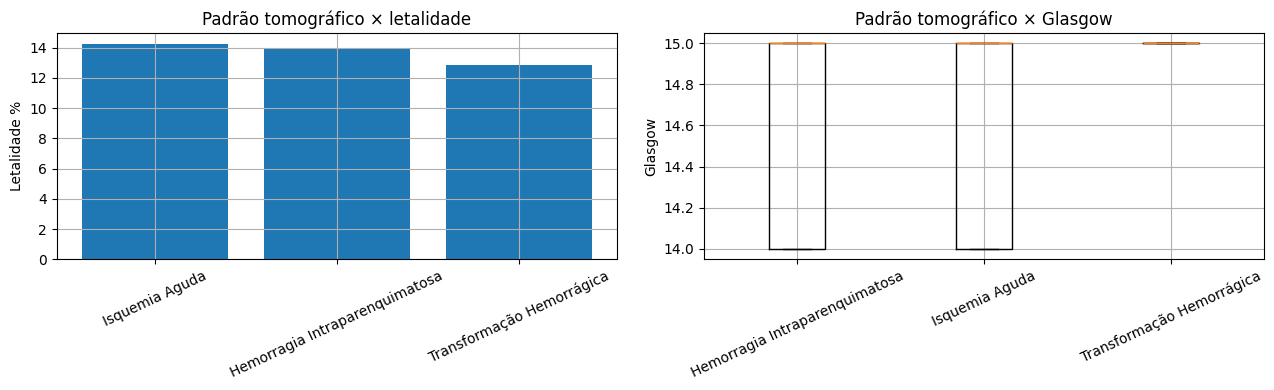

In [ ]:
# Tomografia x óbito e Glasgow
mort=(a.groupby('Tomografia Positiva para AVC')['Óbito'].mean()*100).sort_values(ascending=False)
display(mort.to_frame('Letalidade %').round(2))
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].bar(mort.index,mort.values); axes[0].set_ylabel('Letalidade %'); axes[0].tick_params(axis='x',rotation=25); axes[0].set_title('Padrão tomográfico × letalidade')
patterns=a['Tomografia Positiva para AVC'].dropna().unique()
axes[1].boxplot([a.loc[a['Tomografia Positiva para AVC']==x,'Nível de Consciência (Escala de Glasgow)'] for x in patterns],labels=patterns,showfliers=False); axes[1].tick_params(axis='x',rotation=25); axes[1].set_ylabel('Glasgow'); axes[1].set_title('Padrão tomográfico × Glasgow')
plt.tight_layout(); plt.show()

### AVC — interpretação

Glasgow tem correlação fraca com permanência (rho≈−0,056), porém apresenta **separação extrema por desfecho**: mediana 15 entre sobreviventes e 7 entre óbitos. Esse contraste muito forte, somado ao padrão observado nas demais variáveis de estabilidade, é um sinal de que os dados sintéticos foram provavelmente condicionados ao desfecho. Para ML, isso pode causar **data leakage** e desempenho artificialmente alto. A coluna relevante para AVC é `Tomografia Positiva para AVC`; `Padrão Tomográfico Pulmonar` está corretamente marcado como não aplicável e não deve ser usado no AVC.

## 17. Correlações numéricas

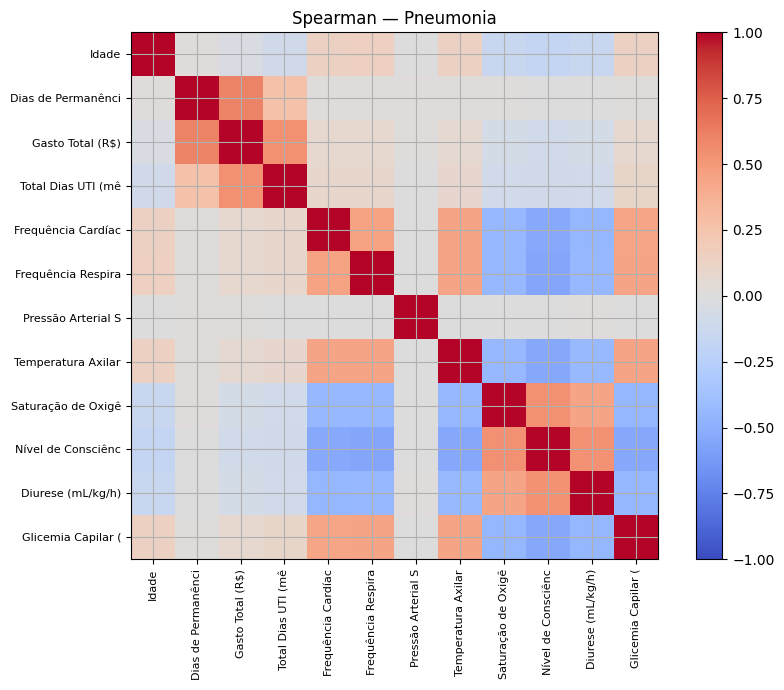

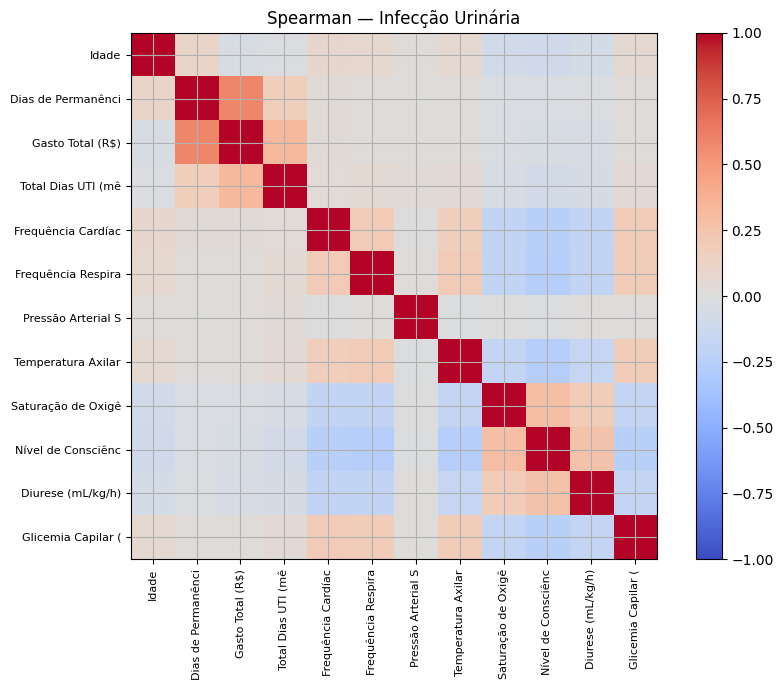

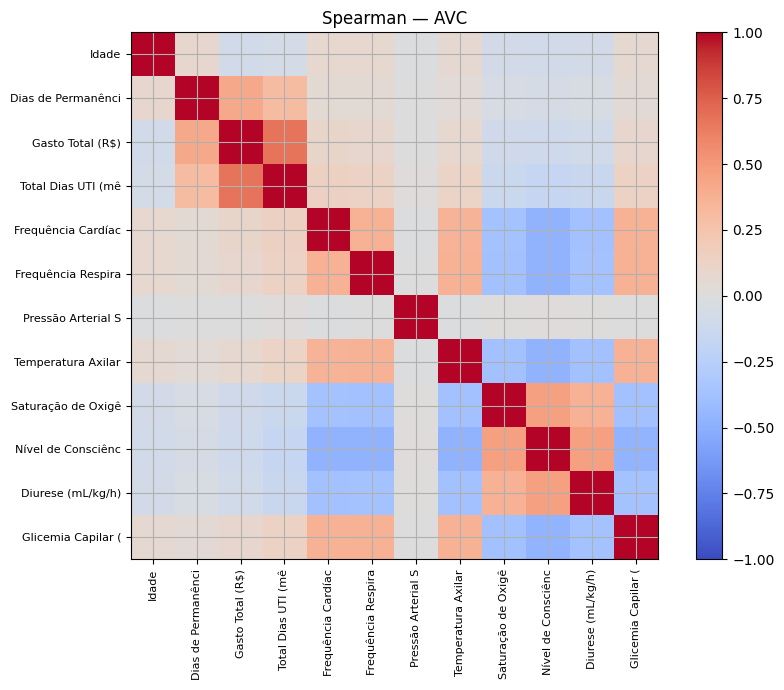

In [ ]:
cols=['Idade','Dias de Permanência','Gasto Total (R$)','Total Dias UTI (mês)','Frequência Cardíaca (bpm)','Frequência Respiratória (irpm)','Pressão Arterial Sistólica (mmHg)','Temperatura Axilar (°C)','Saturação de Oxigênio - SpO2 (%)','Nível de Consciência (Escala de Glasgow)','Diurese (mL/kg/h)','Glicemia Capilar (mg/dL)']
for nome,df in bases.items():
    corr=df[cols].corr(method='spearman')
    fig,ax=plt.subplots(figsize=(9,7)); im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm'); ax.set_xticks(range(len(cols))); ax.set_xticklabels([c[:18] for c in cols],rotation=90,fontsize=8); ax.set_yticks(range(len(cols))); ax.set_yticklabels([c[:18] for c in cols],fontsize=8); ax.set_title(f'Spearman — {nome}'); fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()

## 18. Perfil exploratório de estabilidade/complexidade para o DATCROSS

Para demonstrar a lógica do sistema, será criado um **índice exploratório**, não validado para alta, contando alterações em FC, FR, PAS, temperatura, SpO₂, Glasgow e diurese. Os limites abaixo servem apenas para explorar a estrutura sintética e não constituem protocolo de transferência.

In [ ]:
def criar_instabilidade(df):
    flags=pd.DataFrame(index=df.index)
    flags['FC alterada']=(df['Frequência Cardíaca (bpm)']<50)|(df['Frequência Cardíaca (bpm)']>100)
    flags['FR alterada']=(df['Frequência Respiratória (irpm)']<10)|(df['Frequência Respiratória (irpm)']>24)
    flags['PAS alterada']=(df['Pressão Arterial Sistólica (mmHg)']<90)|(df['Pressão Arterial Sistólica (mmHg)']>180)
    flags['Temperatura alterada']=(df['Temperatura Axilar (°C)']<35)|(df['Temperatura Axilar (°C)']>=38)
    flags['SpO2 baixa']=df['Saturação de Oxigênio - SpO2 (%)']<92
    flags['Glasgow <15']=df['Nível de Consciência (Escala de Glasgow)']<15
    flags['Diurese baixa']=df['Diurese (mL/kg/h)']<0.5
    return flags.sum(axis=1)

inst=[]
for nome,df in bases.items():
    df['Número de Sinais de Instabilidade']=criar_instabilidade(df)
    r,pv=spearmanr(df['Número de Sinais de Instabilidade'],df['Dias de Permanência'])
    inst.append({'Doença':nome,'rho com permanência':r,'p':pv})
    print(); print(nome)
    display(df.groupby('Número de Sinais de Instabilidade').agg(n=('ID Técnico da Internação','size'),Permanência_mediana=('Dias de Permanência','median'),Óbito_pct=('Óbito','mean')).assign(Óbito_pct=lambda x:x['Óbito_pct']*100).round(2))
display(pd.DataFrame(inst).round(4))


Pneumonia


,n,Permanência_mediana,Óbito_pct
Número de Sinais de Instabilidade,,,
0,16331,7.00,0.00
1,2990,7.00,0.00
3,16,5.00,100.00
4,166,7.00,100.00
5,1118,7.00,100.00
6,2270,7.00,100.00
7,615,6.00,100.00



Infecção Urinária


,n,Permanência_mediana,Óbito_pct
Número de Sinais de Instabilidade,,,
0,7798,6.00,0.00
1,1375,6.00,0.00
3,3,5.00,100.00
4,30,6.00,100.00
5,166,6.00,100.00
6,333,7.00,100.00
7,102,7.50,100.00



AVC


,n,Permanência_mediana,Óbito_pct
Número de Sinais de Instabilidade,,,
0,14336,5.00,0.00
1,2459,5.00,0.00
3,6,7.50,100.00
4,98,5.50,100.00
5,744,7.00,100.00
6,1488,6.00,100.00
7,434,6.00,100.00


,Doença,rho com permanência,p
0,Pneumonia,0.00,0.93
1,Infecção Urinária,0.03,0.00
2,AVC,0.06,0.00


In [ ]:
# Quantidade de dispositivos invasivos
DEV=['Sonda Vesical de Demora','Sonda Nasogástrica','Sonda Nasoenteral','Intubação Orotraqueal','Ventilação Mecânica','Cateter Venoso Central','Cateter Central de Inserção Periférica (PICC)']
for nome,df in bases.items():
    df['Número de Dispositivos']=sum((df[c]=='Sim').astype(int) for c in DEV)
    r,pv=spearmanr(df['Número de Dispositivos'],df['Dias de Permanência'])
    print(f'{nome}: dispositivos × permanência rho={r:.3f}')

Pneumonia: dispositivos × permanência rho=0.003
Infecção Urinária: dispositivos × permanência rho=0.042
AVC: dispositivos × permanência rho=0.069


### Achado crítico para o projeto

O índice exploratório revelou um padrão **artificialmente perfeito com óbito**: nos três grupos, pacientes com 0–1 sinais classificados como alterados têm 0% de óbito, enquanto grupos com 3 ou mais alterações têm 100% de óbito. Ao mesmo tempo, o número de sinais alterados apresenta correlação praticamente nula ou muito fraca com dias de permanência.

Isso não é um padrão plausível para ser interpretado como evidência clínica real; é um forte indício de **regra de geração sintética condicionada ao desfecho**. Se um modelo de ML for treinado diretamente nessa base, ele pode atingir excelente acurácia aprendendo a regra usada para criar os dados, e não a fisiologia real dos pacientes.

## 19. Principais insights da AED

1. **Estrutura e integração:** os 52.878 registros possuem ID técnico único e podem ser integrados com segurança por concatenação e identificação do grupo de doença.
2. **Distribuições:** permanência, gasto e UTI são fortemente assimétricos à direita; medianas, IQR, Spearman e testes não paramétricos são mais adequados.
3. **Custos:** permanência é a variável mais consistentemente associada ao gasto (rho 0,42–0,61).
4. **Comorbidades:** HAS e diabetes são as comorbidades mais prevalentes nos três grupos; entretanto, o número total de comorbidades tem associação muito fraca com permanência.
5. **Pneumonia:** SpO₂, FR, DPOC e VM não apresentaram a relação esperada com permanência na base sintética.
6. **ITU:** SVD e distribuição de urocultura são quase independentes; diurese e temperatura têm pouca associação com permanência.
7. **AVC:** Glasgow separa fortemente vivo/óbito, mas pouco explica permanência — padrão compatível com construção sintética baseada no desfecho.
8. **Data leakage:** sinais de instabilidade têm correspondência praticamente determinística com óbito, o que inviabiliza usar a performance de um futuro modelo nessa base como evidência de validade clínica.
9. **Alta/transferência:** comorbidade isolada não deve ser critério de exclusão. O conceito mais coerente para o DATCROSS é combinar estabilidade fisiológica, ausência de suporte intensivo, nível de consciência e dispositivos — porém essa combinação precisa ser validada em dados reais ou em uma base sintética gerada com regras temporais mais realistas.

## 20. Implicações para o DATCROSS

O módulo de NLP deve priorizar a extração estruturada de:

- frequência cardíaca, frequência respiratória, pressão arterial, temperatura e SpO₂;
- Glasgow/nível de consciência;
- diurese;
- necessidade e quantidade de oxigênio;
- ventilação mecânica e intubação;
- uso de UTI;
- dispositivos invasivos;
- comorbidades relevantes;
- evolução clínica e tendência temporal dos sinais vitais;
- plano terapêutico, pendências e critérios explícitos registrados no prontuário.

### Ponto essencial
Para avaliar **alta ou transferência**, uma medida única na admissão não é suficiente. O sistema deverá, futuramente, trabalhar com **tendência temporal** (ex.: estabilidade mantida por determinado período), suporte atual e pendências clínicas. O dataset atual contém essencialmente um retrato sintético e não captura adequadamente a trajetória clínica.

## 21. Limitações

- Parte das variáveis clínicas é sintética e apresenta dependências artificiais com o desfecho.
- Não há séries temporais de sinais vitais; portanto não é possível demonstrar “estabilidade mantida”.
- Não há distância geográfica calculada paciente–hospital; região não deve ser interpretada como distância.
- A base não informa capacidade instalada de leitos; isso exigiria CNES.
- Uso de dispositivos pode ser consequência da gravidade/permanência (causalidade reversa).
- Vacinação possui categoria “Não Informado”, que não deve ser somada a “Não”.
- A base possui alguns registros de leitos pediátricos apesar do recorte adulto, merecendo validação.
- Associações estatísticas em amostra grande podem produzir p-valores baixos mesmo com efeito desprezível.

## 22. Conclusão da AED

A AED demonstrou que a base possui **boa integridade estrutural** para exercícios de integração e análise, com identificadores únicos e baixa ocorrência de `missing` real nas principais variáveis. Internações apresentam distribuição assimétrica de permanência e custos, e o principal padrão administrativo encontrado foi a associação positiva entre tempo de internação, gasto e utilização de UTI.

Do ponto de vista clínico, entretanto, as relações esperadas entre sinais vitais, comorbidades e permanência foram, em geral, fracas ou inexistentes. Simultaneamente, o conjunto de sinais de instabilidade mostrou associação praticamente determinística com óbito. Esse contraste indica que a estrutura sintética atual é útil para demonstrar o **pipeline do DATCROSS**, mas possui limitações importantes para treinar e validar um modelo preditivo de estabilidade, alta ou transferência.

Para as próximas etapas do projeto, recomenda-se que o DATCROSS utilize NLP para transformar informações não estruturadas do prontuário em variáveis clínicas padronizadas e, principalmente, incorporar **temporalidade**: valores seriados de sinais vitais, necessidade atual de suporte, tendência de melhora/piora e pendências assistenciais. Um paciente com hipertensão, diabetes ou outra comorbidade pode estar clinicamente estável; por isso, a decisão de triagem deve priorizar o estado fisiológico atual e sua evolução, e não apenas diagnósticos prévios.

Assim, o resultado mais relevante da AED é metodológico: a futura regra/modelo de triagem deverá ser construída e validada em dados que representem realisticamente a relação entre estabilidade, gravidade e desfecho. O DATCROSS pode então atuar como **ferramenta de priorização**, sinalizando pacientes com perfil de menor complexidade para avaliação de transferência/alta pela equipe assistencial, sem substituir a decisão clínica.

## 23. Próximas etapas recomendadas

1. Revisar a lógica de geração dos sinais vitais sintéticos para remover relações determinísticas com óbito.
2. Criar medidas seriadas/temporais de sinais vitais, em vez de apenas um valor por internação.
3. Definir critérios clínicos de estabilidade com protocolo e validação profissional.
4. Construir features como tendência de SpO₂, necessidade de O₂, Glasgow estável, ausência de VM/UTI e pendências terapêuticas.
5. Separar claramente variáveis disponíveis **antes** da decisão de alta das variáveis que surgem **depois**, prevenindo leakage.
6. Somente depois, treinar modelos e avaliar sensibilidade, especificidade, AUROC e, especialmente, falsos negativos de pacientes instáveis.

## 24. Formato de entrega

O professor solicitou:

- **Notebook:** `EC_Sprint_3_<Nome_Projeto>_<Nome_Grupo>_ML.ipynb`
- **ZIP:** `<nomeRepresentanteRM9999>_Machine_Learning_Sprint3.zip`

Este notebook foi gerado como versão pronta do projeto DATCROSS. Substitua apenas o nome do grupo e do representante/RM caso necessário antes do envio.